# NTK Eigenspace Alignment on $S^1$

This notebook analyzes when the frozen empirical NTK is approximately diagonal in the Fourier basis on the circle.

Let $A = K/n$ be the normalized empirical NTK operator on an evenly spaced grid of angles.
For each frequency $k$, define the Fourier subspace

- $F_0 = \mathrm{span}\{1\}$ (dimension 1),
- $F_k = \mathrm{span}\{\sqrt{2}\cos(k\theta), \sqrt{2}\sin(k\theta)\}$ for $k\ge 1$ (dimension 2).

If $U_k$ is an orthonormal basis for $F_k$, its orthogonal projector is

$$P_k = U_k U_k^\top.$$

From empirical eigenvectors of $A$, we construct a matched subspace $\hat{F}_k$ (same dimension as $F_k$), with projector

$$\hat{P}_k = \hat{U}_k \hat{U}_k^\top.$$

We compare $P_k$ and $\hat{P}_k$ instead of comparing single vectors directly because signs and rotations inside a degenerate/near-degenerate 2D eigenspace are arbitrary.
Projector metrics remove this basis-choice ambiguity.

### $P_k$

- $P_k$ captures whether the *subspace* spanned by NTK eigenvectors matches the Fourier mode pair at frequency $k$.
- Small $\|\hat{P}_k - P_k\|$ means little leakage into other frequencies and good Fourier-mode isolation.
- Large distance means frequency mixing and weaker validity of frozen-kernel Fourier mode analysis at that width.

### Distances and angles

Using principal angles $\theta_i$ between $F_k$ and $\hat{F}_k$:

$$\|\hat{P}_k - P_k\|_F^2 = 2\sum_i \sin^2\theta_i, \qquad \|\hat{P}_k - P_k\|_{op} = \max_i \sin\theta_i.$$

Interpretation:

- value near 0: excellent alignment,
- larger value: stronger mismatch (for 2D subspaces, Frobenius distance ranges from 0 to 2).

This directly answers the width question: *when does frozen NTK become Fourier-aligned enough for mode-wise theory to be reliable?*

## Experiment Setup

- Domain: equally spaced grid $\theta_i = 2\pi i / n$, embedded as $x(\theta)=(\cos\theta,\sin\theta)$.
- Model: one-hidden-layer ReLU network in NTK parameterization, frozen at initialization.
- Width sweep: compare multiple widths and seeds.
- Operator: $A = K / n$ where $K$ is empirical NTK on the grid.

For each frequency $k$, with Fourier subspace $F_k$ (dimension 1 for $k=0$, dimension 2 for $k\ge 1$):

1. Compute overlaps $\|P_k v_j\|^2$ between empirical eigenvectors $v_j$ and Fourier projector $P_k$.
2. Select top empirical eigenvectors to define $\hat{F}_k$.
3. Compare projectors and principal angles between $F_k$ and $\hat{F}_k$.

Key metrics:

- Projector distances: $\|\hat{P}_k - P_k\|_F$, $\|\hat{P}_k - P_k\|_{op}$.
- Principal angles between $F_k$ and $\hat{F}_k$.
- Eigenvalue alignment error and pair splitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from utils.artifacts_io import latest_run_dir, load_manifest, npz

BASE = Path('../results')
EXP_NAME = 'ntk_eigenspace_alignment_on_S1'
PLOT_DIR = Path('plots') / EXP_NAME
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

print('Plots will be saved to:', PLOT_DIR)

Plots will be saved to: plots/ntk_eigenspace_alignment_on_S1


In [2]:
run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
summary = npz(run_dir, manifest['summary'])
basis = npz(run_dir, manifest['basis_metadata'])
probe = npz(run_dir, manifest['probe_geometry'])

if not bool(manifest.get('meta', {}).get('save_aligned_eigvecs', False)):
    raise RuntimeError(
        'This notebook now assumes new runs with artifacts.save_aligned_eigvecs=true.'
    )

theta = np.asarray(probe['theta'], dtype=float)
n_points = int(manifest['meta']['n_points'])

widths = np.asarray(summary['widths'], dtype=int)
frequencies = np.asarray(summary['frequencies'], dtype=int)
projector_fro_mean = np.asarray(summary['projector_fro_mean'], dtype=float)
projector_fro_std = np.asarray(summary['projector_fro_std'], dtype=float)
projector_op_mean = np.asarray(summary['projector_op_mean'], dtype=float)
projector_op_std = np.asarray(summary['projector_op_std'], dtype=float)
principal_angles_mean = np.asarray(summary['principal_angles_mean'], dtype=float)
principal_angles_std = np.asarray(summary['principal_angles_std'], dtype=float)
eig_abs_error_mean = np.asarray(summary['eig_abs_error_mean'], dtype=float)
eig_abs_error_std = np.asarray(summary['eig_abs_error_std'], dtype=float)
pair_splitting_mean = np.asarray(summary['pair_splitting_mean'], dtype=float)
pair_splitting_std = np.asarray(summary['pair_splitting_std'], dtype=float)
lambda_theory = np.asarray(summary['lambda_theory'], dtype=float)
min_width_for_small_error = np.asarray(summary['min_width_for_small_error'], dtype=int)
failing_freqs_at_max_width = np.asarray(summary['failing_freqs_at_max_width'], dtype=int)
projector_fro_tol = float(np.ravel(summary['projector_fro_tol'])[0])

mode_names = basis.get('mode_names')

print('Loaded run dir:', run_dir)
print('n_points:', n_points)
print('widths:', widths.tolist())
print('frequencies:', frequencies.tolist())
print('projector_fro_tol:', projector_fro_tol)

Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/ntk_eigenspace_alignment_on_S1/20260416-120300-8ee36e9b
n_points: 2048
widths: [32, 64, 128, 256, 512, 1024]
frequencies: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
projector_fro_tol: 0.25


In [3]:
def fidx(k: int) -> int:
    matches = np.where(frequencies == int(k))[0]
    if len(matches) == 0:
        raise ValueError(f'Frequency {k} not in run frequencies {frequencies.tolist()}')
    return int(matches[0])

def widx(w: int) -> int:
    matches = np.where(widths == int(w))[0]
    if len(matches) == 0:
        raise ValueError(f'Width {w} not in run widths {widths.tolist()}')
    return int(matches[0])

def keep_existing(items, allowed):
    allowed = set(allowed)
    return [x for x in items if x in allowed]

def fourier_frame(theta, k: int):
    k = int(k)
    theta = np.asarray(theta, dtype=float)

    if k == 0:
        F = np.ones((len(theta), 1), dtype=float)
        labels = [r'$\phi_0(\theta)=1$']
    else:
        F = np.stack([
            np.sqrt(2.0) * np.cos(k * theta),
            np.sqrt(2.0) * np.sin(k * theta),
        ], axis=1)
        labels = [rf'$\sqrt{{2}}\cos({k}\theta)$', rf'$\sqrt{{2}}\sin({k}\theta)$']

    F = F / (np.linalg.norm(F, axis=0, keepdims=True) + 1e-12)
    F, _ = np.linalg.qr(F)
    return F.astype(np.float32), labels

_width_run_cache = {}
_multi_seed_cache = {}

def get_width_run(width: int):
    width = int(width)
    if width not in _width_run_cache:
        run = npz(run_dir, manifest['runs'][str(width)])
        required = ['aligned_eigvecs', 'fourier_coeffs_raw', 'fourier_coeffs_aligned']
        missing = [k for k in required if k not in run]
        if missing:
            raise RuntimeError(
                f'Run file for width={width} is missing keys {missing}. '
                'Please rerun experiment with the latest script and artifacts.save_aligned_eigvecs=true.'
            )
        _width_run_cache[width] = run
    return _width_run_cache[width]

def aligned_components_across_seeds(width: int, k: int, seeds=None):
    width = int(width)
    k = int(k)

    run = get_width_run(width)
    run_seeds = np.asarray(run['seeds'], dtype=int)
    run_freqs = np.asarray(run['frequencies'], dtype=int)

    f_matches = np.where(run_freqs == k)[0]
    if len(f_matches) != 1:
        raise ValueError(f'Frequency {k} not found in run frequencies {run_freqs.tolist()}')
    f_idx = int(f_matches[0])

    if seeds is None:
        seeds = run_seeds
    seeds = np.asarray(seeds, dtype=int)

    cache_key = (width, k, tuple(seeds.tolist()))
    if cache_key in _multi_seed_cache:
        return _multi_seed_cache[cache_key]

    seed_indices = []
    for s in seeds:
        matches = np.where(run_seeds == int(s))[0]
        if len(matches) != 1:
            raise ValueError(f'Seed {int(s)} not found for width {width}; available {run_seeds.tolist()}')
        seed_indices.append(int(matches[0]))

    seed_indices = np.asarray(seed_indices, dtype=int)

    F, labels = fourier_frame(theta, k)
    d = F.shape[1]

    aligned_all = np.asarray(run['aligned_eigvecs'], dtype=np.float32)
    aligned = aligned_all[seed_indices, f_idx, :d, :]
    mean = np.mean(aligned, axis=0)
    std = np.std(aligned, axis=0)

    coeff_raw_all = np.asarray(run['fourier_coeffs_raw'], dtype=np.float32)
    coeff_aligned_all = np.asarray(run['fourier_coeffs_aligned'], dtype=np.float32)
    coeff_raw = coeff_raw_all[seed_indices, f_idx, :d, :d]
    coeff_aligned = coeff_aligned_all[seed_indices, f_idx, :d, :d]

    eig_idx_all = np.asarray(run['selected_eig_indices'], dtype=int)
    eigvals_all = np.asarray(run['selected_eigvals'], dtype=np.float32)
    eig_idx = eig_idx_all[seed_indices, f_idx, :d]
    eigvals = eigvals_all[seed_indices, f_idx, :d]

    out = {
        'width': width,
        'k': k,
        'seeds': seeds,
        'F': F,
        'labels': labels,
        'd': d,
        'aligned': aligned,  # [S, d, n_points]
        'mean': mean,        # [d, n_points]
        'std': std,          # [d, n_points]
        'coeff_raw': coeff_raw,          # [S, d, d]
        'coeff_aligned': coeff_aligned,  # [S, d, d]
        'eig_idx': eig_idx,  # [S, d]
        'eigvals': eigvals,  # [S, d]
        'source': 'saved',
    }

    _multi_seed_cache[cache_key] = out
    return out


## Visual Check: NTK Eigenvectors vs Fourier Waves

Let $U_k$ be an orthonormal Fourier frame (columns are cos/sin for frequency $k$), and let $V_k$ be the selected empirical NTK eigenvectors for that frequency.

Raw overlap matrix:

$$M_{raw} = V_k^\top U_k.$$

- Each **row** of $M_{raw}$ gives one empirical eigenvector's coordinates on the $(\cos(k\theta),\sin(k\theta))$ axes.
- If the subspace aligns but basis is rotated, $M_{raw}$ can look like a 2D rotation/mix, not identity.

Alignment step (orthogonal Procrustes): choose

$$R = \arg\min_{Q\in O(d)} \|V_k Q - U_k\|_F,$$

implemented via SVD of $M_{raw}$, then

$$V_k^{align} = V_k R.$$

After this, the aligned overlap matrix

$$M_{align} = (V_k^{align})^\top U_k$$

is close to identity when alignment is good.

So:
- **raw view** shows how empirical vectors are oriented in the Fourier plane,
- **aligned view** factors out basis rotation/sign ambiguity and shows subspace agreement.


Inspecting width=256, seed=0, k=2
selected empirical eigenvalue indices: [4, 3]
selected empirical eigenvalues: [0.09235960245132446, 0.09619487076997757]
projector_fro=1.7170e-01, projector_op=9.9181e-02
principal angles (deg): [4.015370029081177, 5.691991078796193]
M_raw = V^T U:
 [[-0.97007287 -0.22874314]
 [-0.22627372  0.9698945 ]]
M_align = (V_align)^T U:
 [[0.99611104 0.00122266]
 [0.00122217 0.99650127]]
Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_shape_single_seed_w256_seed0_k2.png


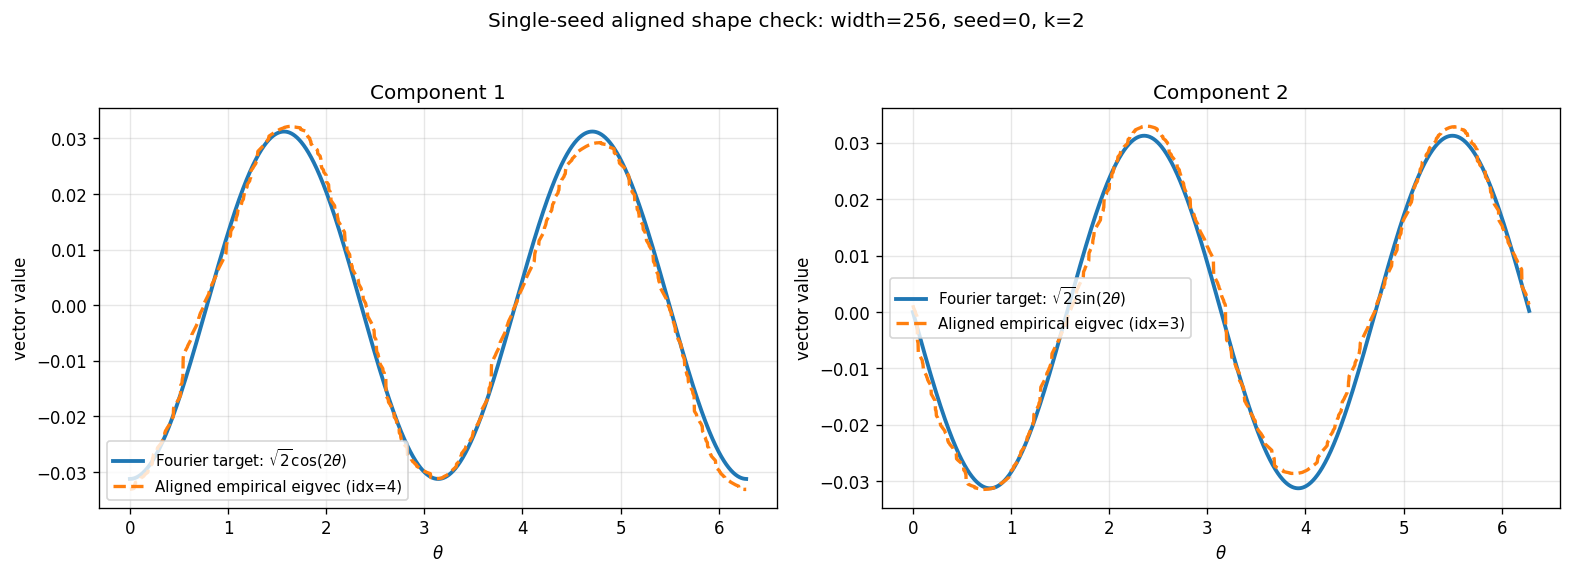

In [15]:
# Choose one (width, seed, frequency) to inspect.
INSPECT_WIDTH = 256 # int(widths[-1])
INSPECT_SEED = int(manifest['meta']['seeds'][0])
INSPECT_K = 2

single = aligned_components_across_seeds(INSPECT_WIDTH, INSPECT_K, seeds=[INSPECT_SEED])

F = single['F']
labels = single['labels']
d = single['d']
aligned = single['aligned'][0]
eig_idx = single['eig_idx'][0]
eigvals = single['eigvals'][0]
M_raw = single['coeff_raw'][0]
M_align = single['coeff_aligned'][0]

width_run = get_width_run(INSPECT_WIDTH)
seeds_w = np.asarray(width_run['seeds'], dtype=int)
freqs_w = np.asarray(width_run['frequencies'], dtype=int)
s_idx = int(np.where(seeds_w == INSPECT_SEED)[0][0])
f_idx = int(np.where(freqs_w == INSPECT_K)[0][0])
proj_fro_seed = float(width_run['projector_fro'][s_idx, f_idx])
proj_op_seed = float(width_run['projector_op'][s_idx, f_idx])
angles_seed = np.asarray(width_run['principal_angles'][s_idx, f_idx], dtype=float)
angles_seed = angles_seed[~np.isnan(angles_seed)]

print(f'Inspecting width={INSPECT_WIDTH}, seed={INSPECT_SEED}, k={INSPECT_K}')
print('selected empirical eigenvalue indices:', eig_idx.tolist())
print('selected empirical eigenvalues:', eigvals.tolist())
print(f'projector_fro={proj_fro_seed:.4e}, projector_op={proj_op_seed:.4e}')
if len(angles_seed) > 0:
    print('principal angles (deg):', np.rad2deg(angles_seed).tolist())
print('M_raw = V^T U:\n', M_raw)
print('M_align = (V_align)^T U:\n', M_align)

fig, axes = plt.subplots(1, d, figsize=(6.6 * d, 4.6), sharex=True)
if d == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    ax.plot(theta, F[:, j], linewidth=2.3, label=f'Fourier target: {labels[j]}')
    ax.plot(theta, aligned[j, :], linewidth=2.0, linestyle='--', label=f'Aligned empirical eigvec (idx={int(eig_idx[j])})')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel('vector value')
    ax.set_title(f'Component {j + 1}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle(
    f'Single-seed aligned shape check: width={INSPECT_WIDTH}, seed={INSPECT_SEED}, k={INSPECT_K}',
    y=1.03,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_shape_single_seed_w{INSPECT_WIDTH}_seed{INSPECT_SEED}_k{INSPECT_K}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## Raw vs Aligned in the Fourier Plane (cos on x, sin on y)

For $k\ge 1$, each selected empirical eigenvector gives a point $(\langle v,\cos(k\theta)\rangle, \langle v,\sin(k\theta)\rangle)$.

- Left plot: raw coordinates from $M_{raw}=V^TU$.
- Right plot: aligned coordinates from $M_{align}=(V_{align})^TU$.

If subspace alignment is good, raw points may be rotated/mixed, while aligned points should move toward basis axes.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_fourier_plane_raw_vs_aligned_w256_k5.png


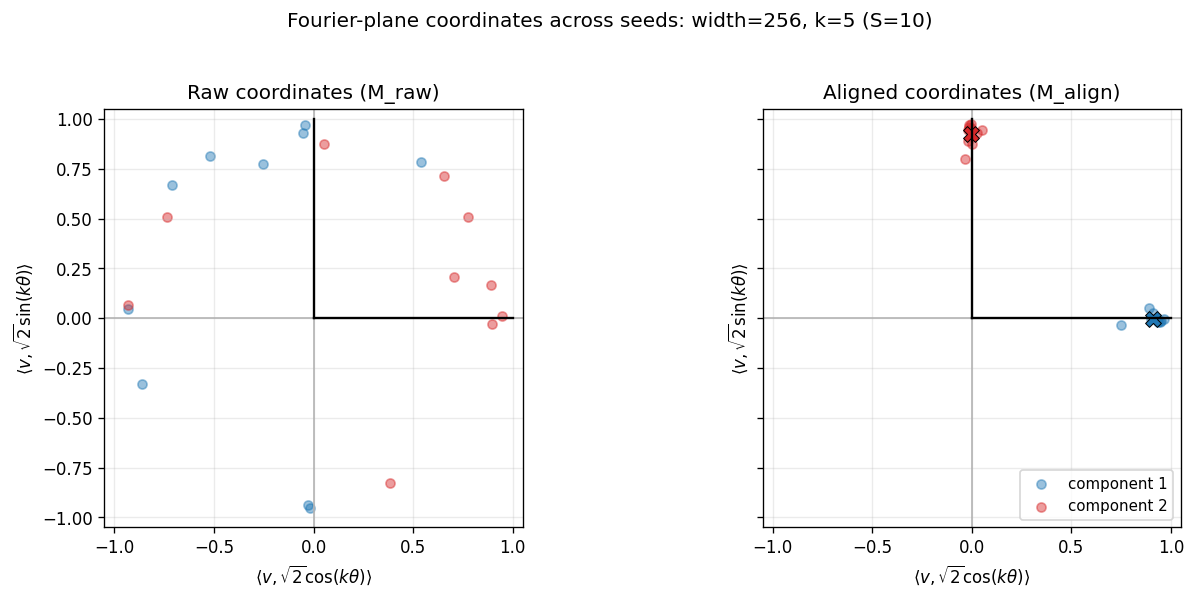

In [16]:
PLANE_WIDTH = 256 #int(widths[-1])
PLANE_K = 5

plane = aligned_components_across_seeds(PLANE_WIDTH, PLANE_K)
if plane['d'] != 2:
    raise ValueError('cos/sin plane plot requires k >= 1 (2D subspace).')

raw = plane['coeff_raw']         # [S,2,2]
aligned = plane['coeff_aligned'] # [S,2,2]
seeds_used = plane['seeds']

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8), sharex=True, sharey=True)
titles = ['Raw coordinates (M_raw)', 'Aligned coordinates (M_align)']
mats = [raw, aligned]
colors = ['C0', 'C3']  # comp1, comp2
labels_comp = ['component 1', 'component 2']

for ax, title, mats_s in zip(axes, titles, mats):
    ax.axhline(0.0, color='0.7', linewidth=1.0)
    ax.axvline(0.0, color='0.7', linewidth=1.0)
    ax.plot([0, 1], [0, 0], color='black', linewidth=1.4)
    ax.plot([0, 0], [0, 1], color='black', linewidth=1.4)

    for comp in range(2):
        xs = mats_s[:, comp, 0]
        ys = mats_s[:, comp, 1]
        ax.scatter(xs, ys, s=30, alpha=0.45, color=colors[comp], label=labels_comp[comp])
        if title != 'Raw coordinates (M_raw)':
            ax.scatter([np.mean(xs)], [np.mean(ys)], s=90, marker='X', color=colors[comp], edgecolor='black', linewidth=0.6)

    lim = 1.05
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(r'$\langle v, \sqrt{2}\cos(k\theta)\rangle$')
    ax.set_ylabel(r'$\langle v, \sqrt{2}\sin(k\theta)\rangle$')
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

axes[1].legend(loc='lower right', fontsize=9)
fig.suptitle(
    f'Fourier-plane coordinates across seeds: width={PLANE_WIDTH}, k={PLANE_K} (S={len(seeds_used)})',
    y=1.03,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_fourier_plane_raw_vs_aligned_w{PLANE_WIDTH}_k{PLANE_K}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## Raw Fourier-Plane Coordinates Across Multiple Frequencies

This is the pre-Procrustes view. For each frequency $k\ge 1$, each selected empirical eigenvector gives a point
$$(x,y)=\big(\langle v,\sqrt{2}\cos(k\theta)\rangle,\;\langle v,\sqrt{2}\sin(k\theta)\rangle\big).$$

If the NTK subspace is close but rotated, these clouds are structured but not axis-aligned.
After Procrustes, the same clouds become close to basis axes/identity coordinates.


Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_fourier_plane_raw_multi_freq_w256.png


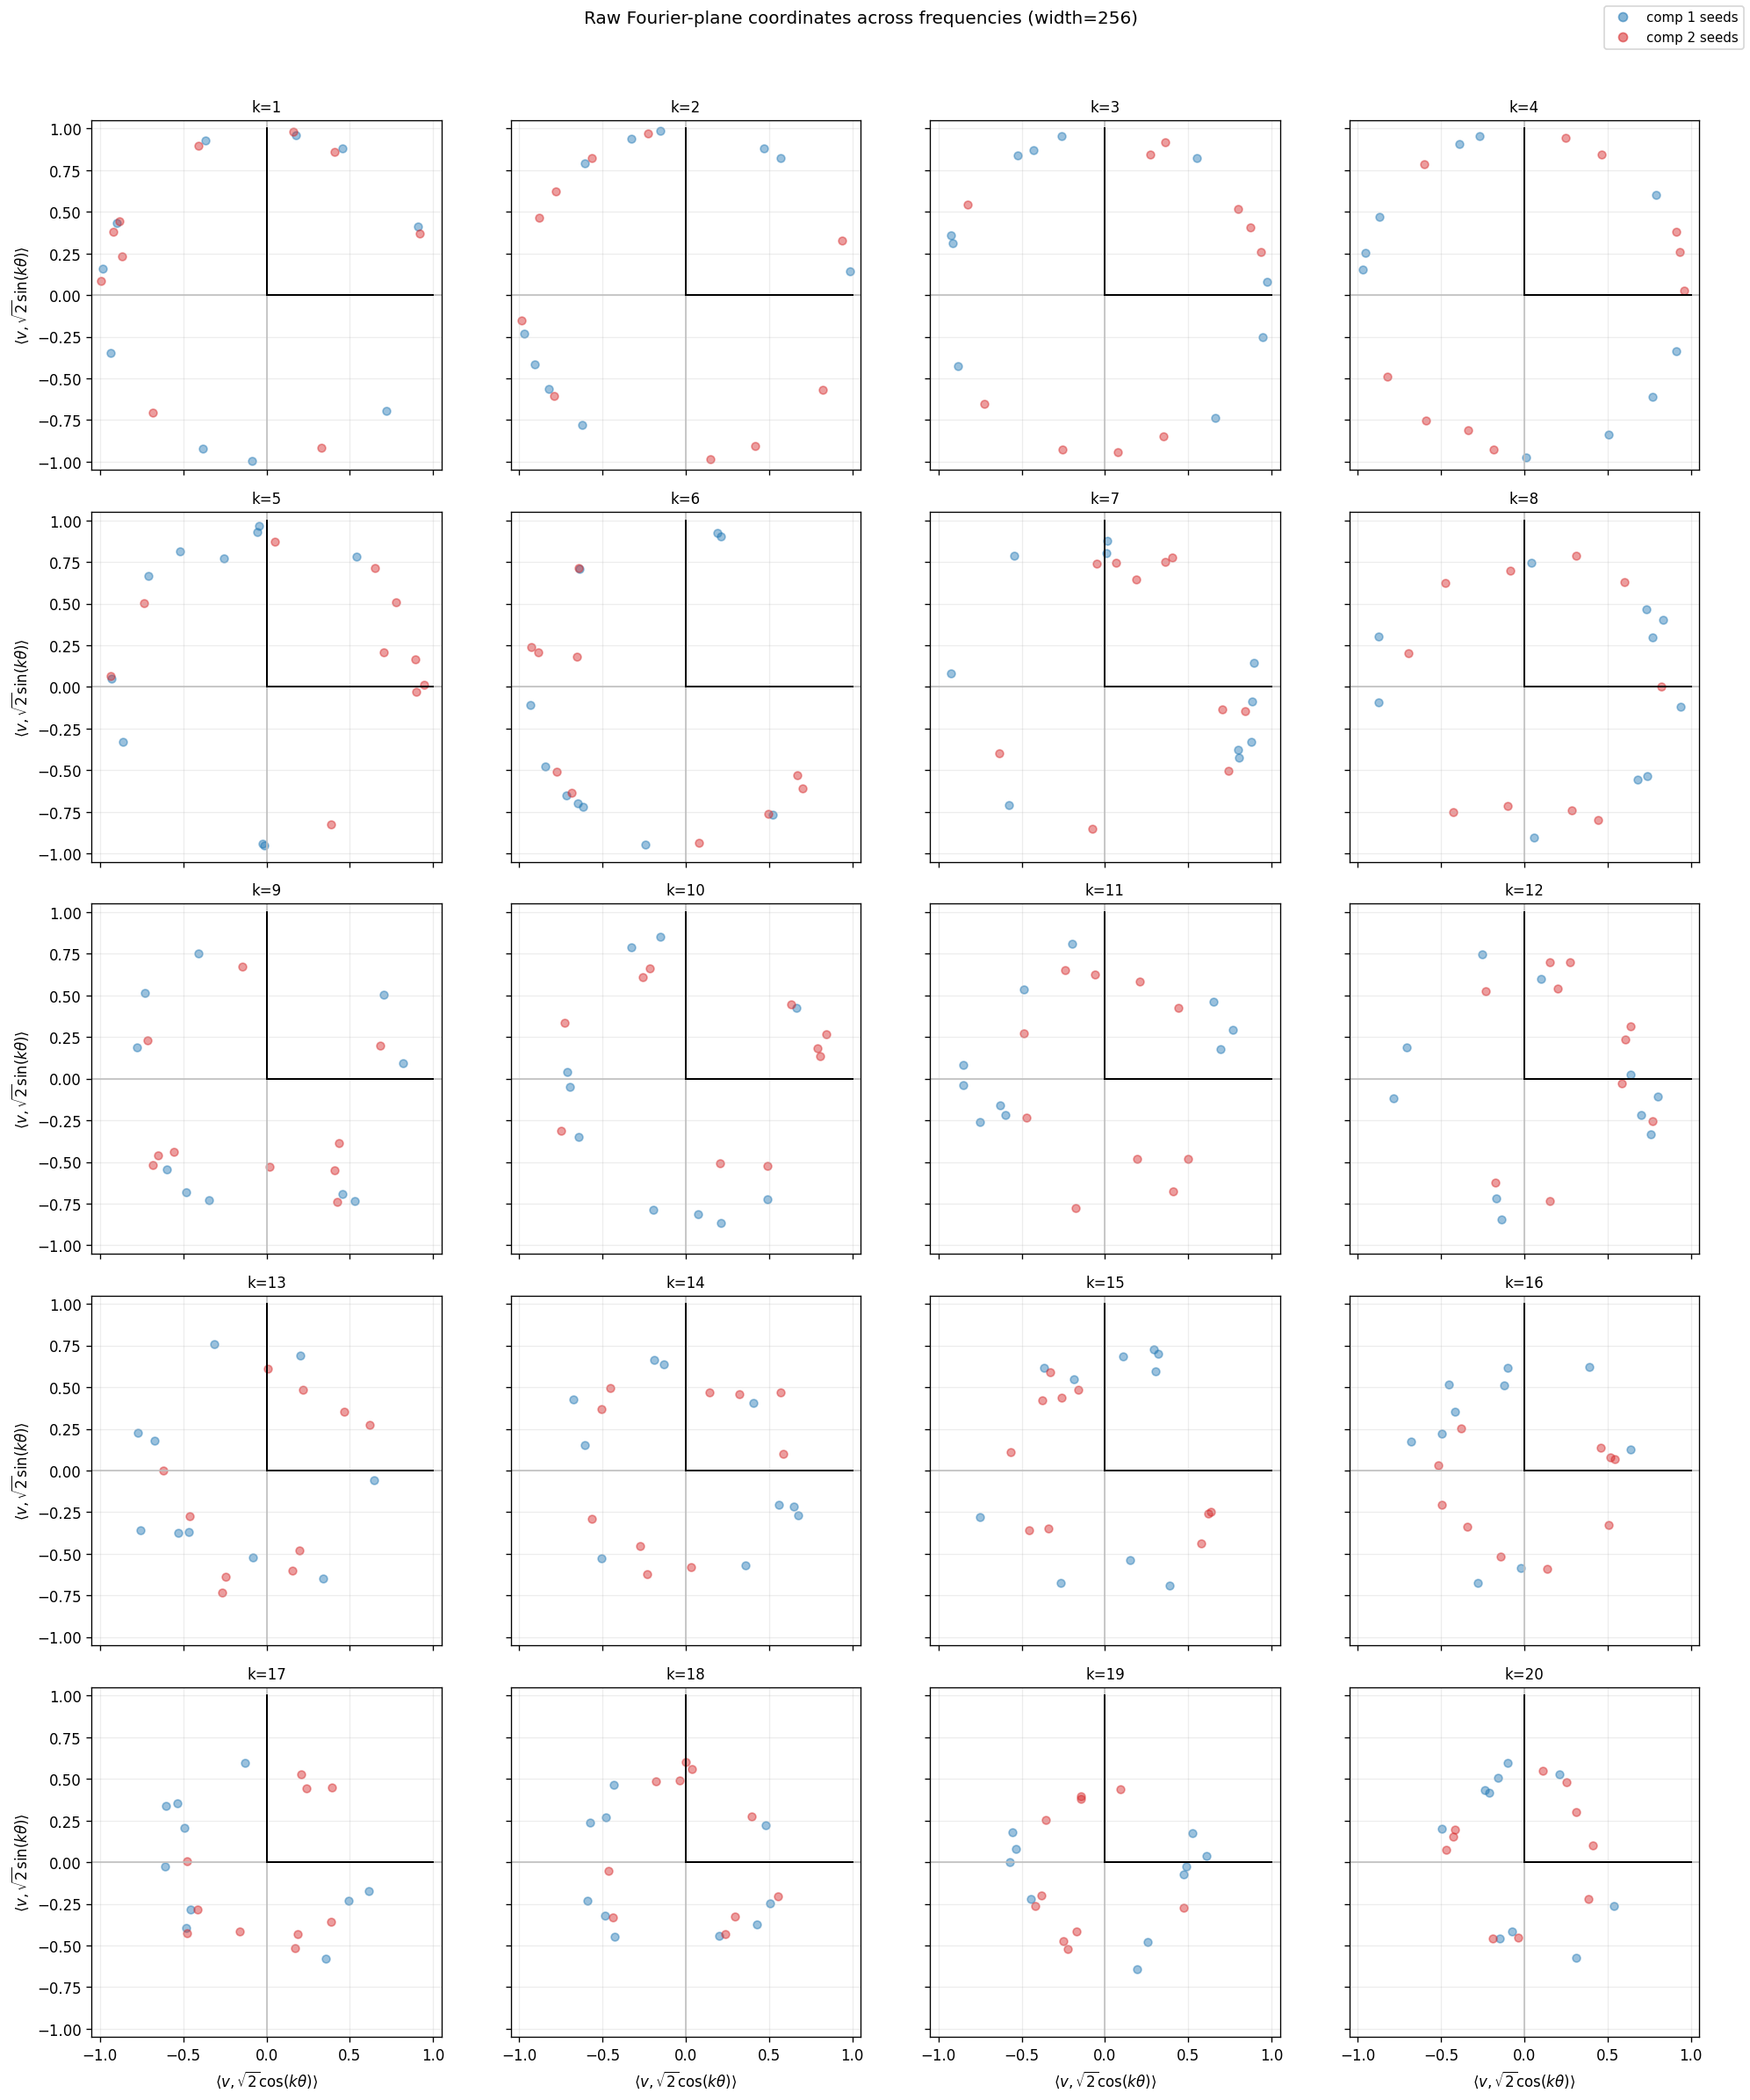

In [17]:
RAW_MULTI_WIDTH = 256 #int(widths[-1])
RAW_MULTI_FREQS = keep_existing(frequencies.tolist(), frequencies.tolist())
RAW_MULTI_FREQS = [int(k) for k in RAW_MULTI_FREQS if int(k) >= 1]
RAW_MULTI_NCOLS = 4

if len(RAW_MULTI_FREQS) == 0:
    raise RuntimeError('No frequencies >=1 available for raw multi-frequency plane plot.')

n_panels = len(RAW_MULTI_FREQS)
n_cols = min(RAW_MULTI_NCOLS, n_panels)
n_rows = int(np.ceil(n_panels / n_cols))

max_dim = max(n_rows, n_cols)
if max_dim >= 8:
    width_per_col, height_per_row = 4.8, 4.4
elif max_dim >= 6:
    width_per_col, height_per_row = 4.5, 4.1
else:
    width_per_col, height_per_row = 4.2, 3.9

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(width_per_col * n_cols, height_per_row * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.asarray(axes).reshape(-1)

for panel_idx, k in enumerate(RAW_MULTI_FREQS):
    ax = axes[panel_idx]
    st = aligned_components_across_seeds(RAW_MULTI_WIDTH, int(k))
    if st['d'] != 2:
        ax.axis('off')
        continue

    raw = st['coeff_raw']  # [S,2,2]

    ax.axhline(0.0, color='0.75', linewidth=1.0)
    ax.axvline(0.0, color='0.75', linewidth=1.0)
    ax.plot([0, 1], [0, 0], color='black', linewidth=1.2)
    ax.plot([0, 0], [0, 1], color='black', linewidth=1.2)

    for comp, color in enumerate(['C0', 'C3']):
        xs = raw[:, comp, 0]
        ys = raw[:, comp, 1]
        ax.scatter(xs, ys, s=28, alpha=0.45, color=color)

    ax.set_title(f'k={int(k)}', fontsize=10)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.22)

for j in range(n_panels, len(axes)):
    axes[j].axis('off')

for r in range(n_rows):
    for c in range(n_cols):
        idx = r * n_cols + c
        if idx >= len(axes) or idx >= n_panels:
            continue
        ax = axes[idx]
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        if r == n_rows - 1:
            ax.set_xlabel(r'$\langle v, \sqrt{2}\cos(k\theta)\rangle$')
        if c == 0:
            ax.set_ylabel(r'$\langle v, \sqrt{2}\sin(k\theta)\rangle$')

legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='None', color='C0', alpha=0.55, label='comp 1 seeds'),
    plt.Line2D([0], [0], marker='o', linestyle='None', color='C3', alpha=0.55, label='comp 2 seeds'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9)
fig.suptitle(
    f'Raw Fourier-plane coordinates across frequencies (width={RAW_MULTI_WIDTH})',
    y=1.02,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_fourier_plane_raw_multi_freq_w{RAW_MULTI_WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## Multi-Seed Mean ± Spread: Eigenvector Shapes

This view aggregates all seeds for one `(width, k)`. The band is mean ± std across seeds of the aligned empirical component values at each angle.

width=256, k=5, seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
component source: saved
Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_shape_mean_spread_w256_k5.png


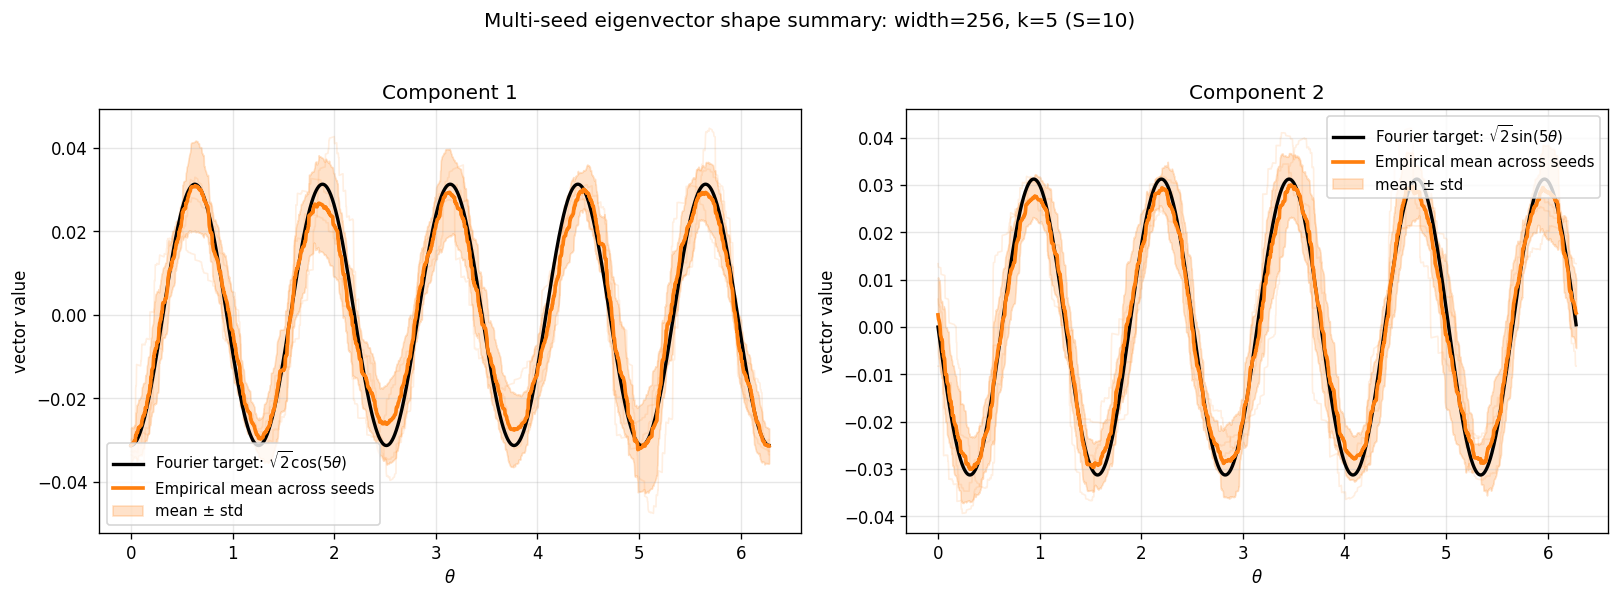

In [19]:
MEAN_WIDTH = 256 #int(widths[-1])
MEAN_K = 5
SHOW_FEW_SEEDS = 3  # light overlay for a few seeds

multi = aligned_components_across_seeds(MEAN_WIDTH, MEAN_K)
F = multi['F']
labels = multi['labels']
d = multi['d']
aligned = multi['aligned']
mean = multi['mean']
std = multi['std']
seed_ids = multi['seeds']

print(f'width={MEAN_WIDTH}, k={MEAN_K}, seeds={seed_ids.tolist()}')
print('component source:', multi['source'])

fig, axes = plt.subplots(1, d, figsize=(6.8 * d, 4.8), sharex=True)
if d == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    for s in range(min(SHOW_FEW_SEEDS, aligned.shape[0])):
        ax.plot(theta, aligned[s, j, :], color='C1', alpha=0.12, linewidth=1.0)

    ax.plot(theta, F[:, j], color='black', linewidth=2.0, label=f'Fourier target: {labels[j]}')
    ax.plot(theta, mean[j, :], color='C1', linewidth=2.2, label='Empirical mean across seeds')
    ax.fill_between(theta, mean[j, :] - std[j, :], mean[j, :] + std[j, :], color='C1', alpha=0.22, label='mean ± std')

    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel('vector value')
    ax.set_title(f'Component {j + 1}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle(
    f'Multi-seed eigenvector shape summary: width={MEAN_WIDTH}, k={MEAN_K} (S={aligned.shape[0]})',
    y=1.03,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_shape_mean_spread_w{MEAN_WIDTH}_k{MEAN_K}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Grid View (4x4 or 8x8) of Multiple Components

Each panel shows Fourier target (black) and empirical mean ± std across seeds (orange band) for one `(frequency, component)` pair.
Set `GRID_ROWS` and `GRID_COLS` to `4,4` or `8,8` as needed.

Grid width=256, panels=14, frequencies=[2, 3, 4, 5, 6, 7, 8], data source=['saved']
Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvector_shape_grid_6x6_w256.png


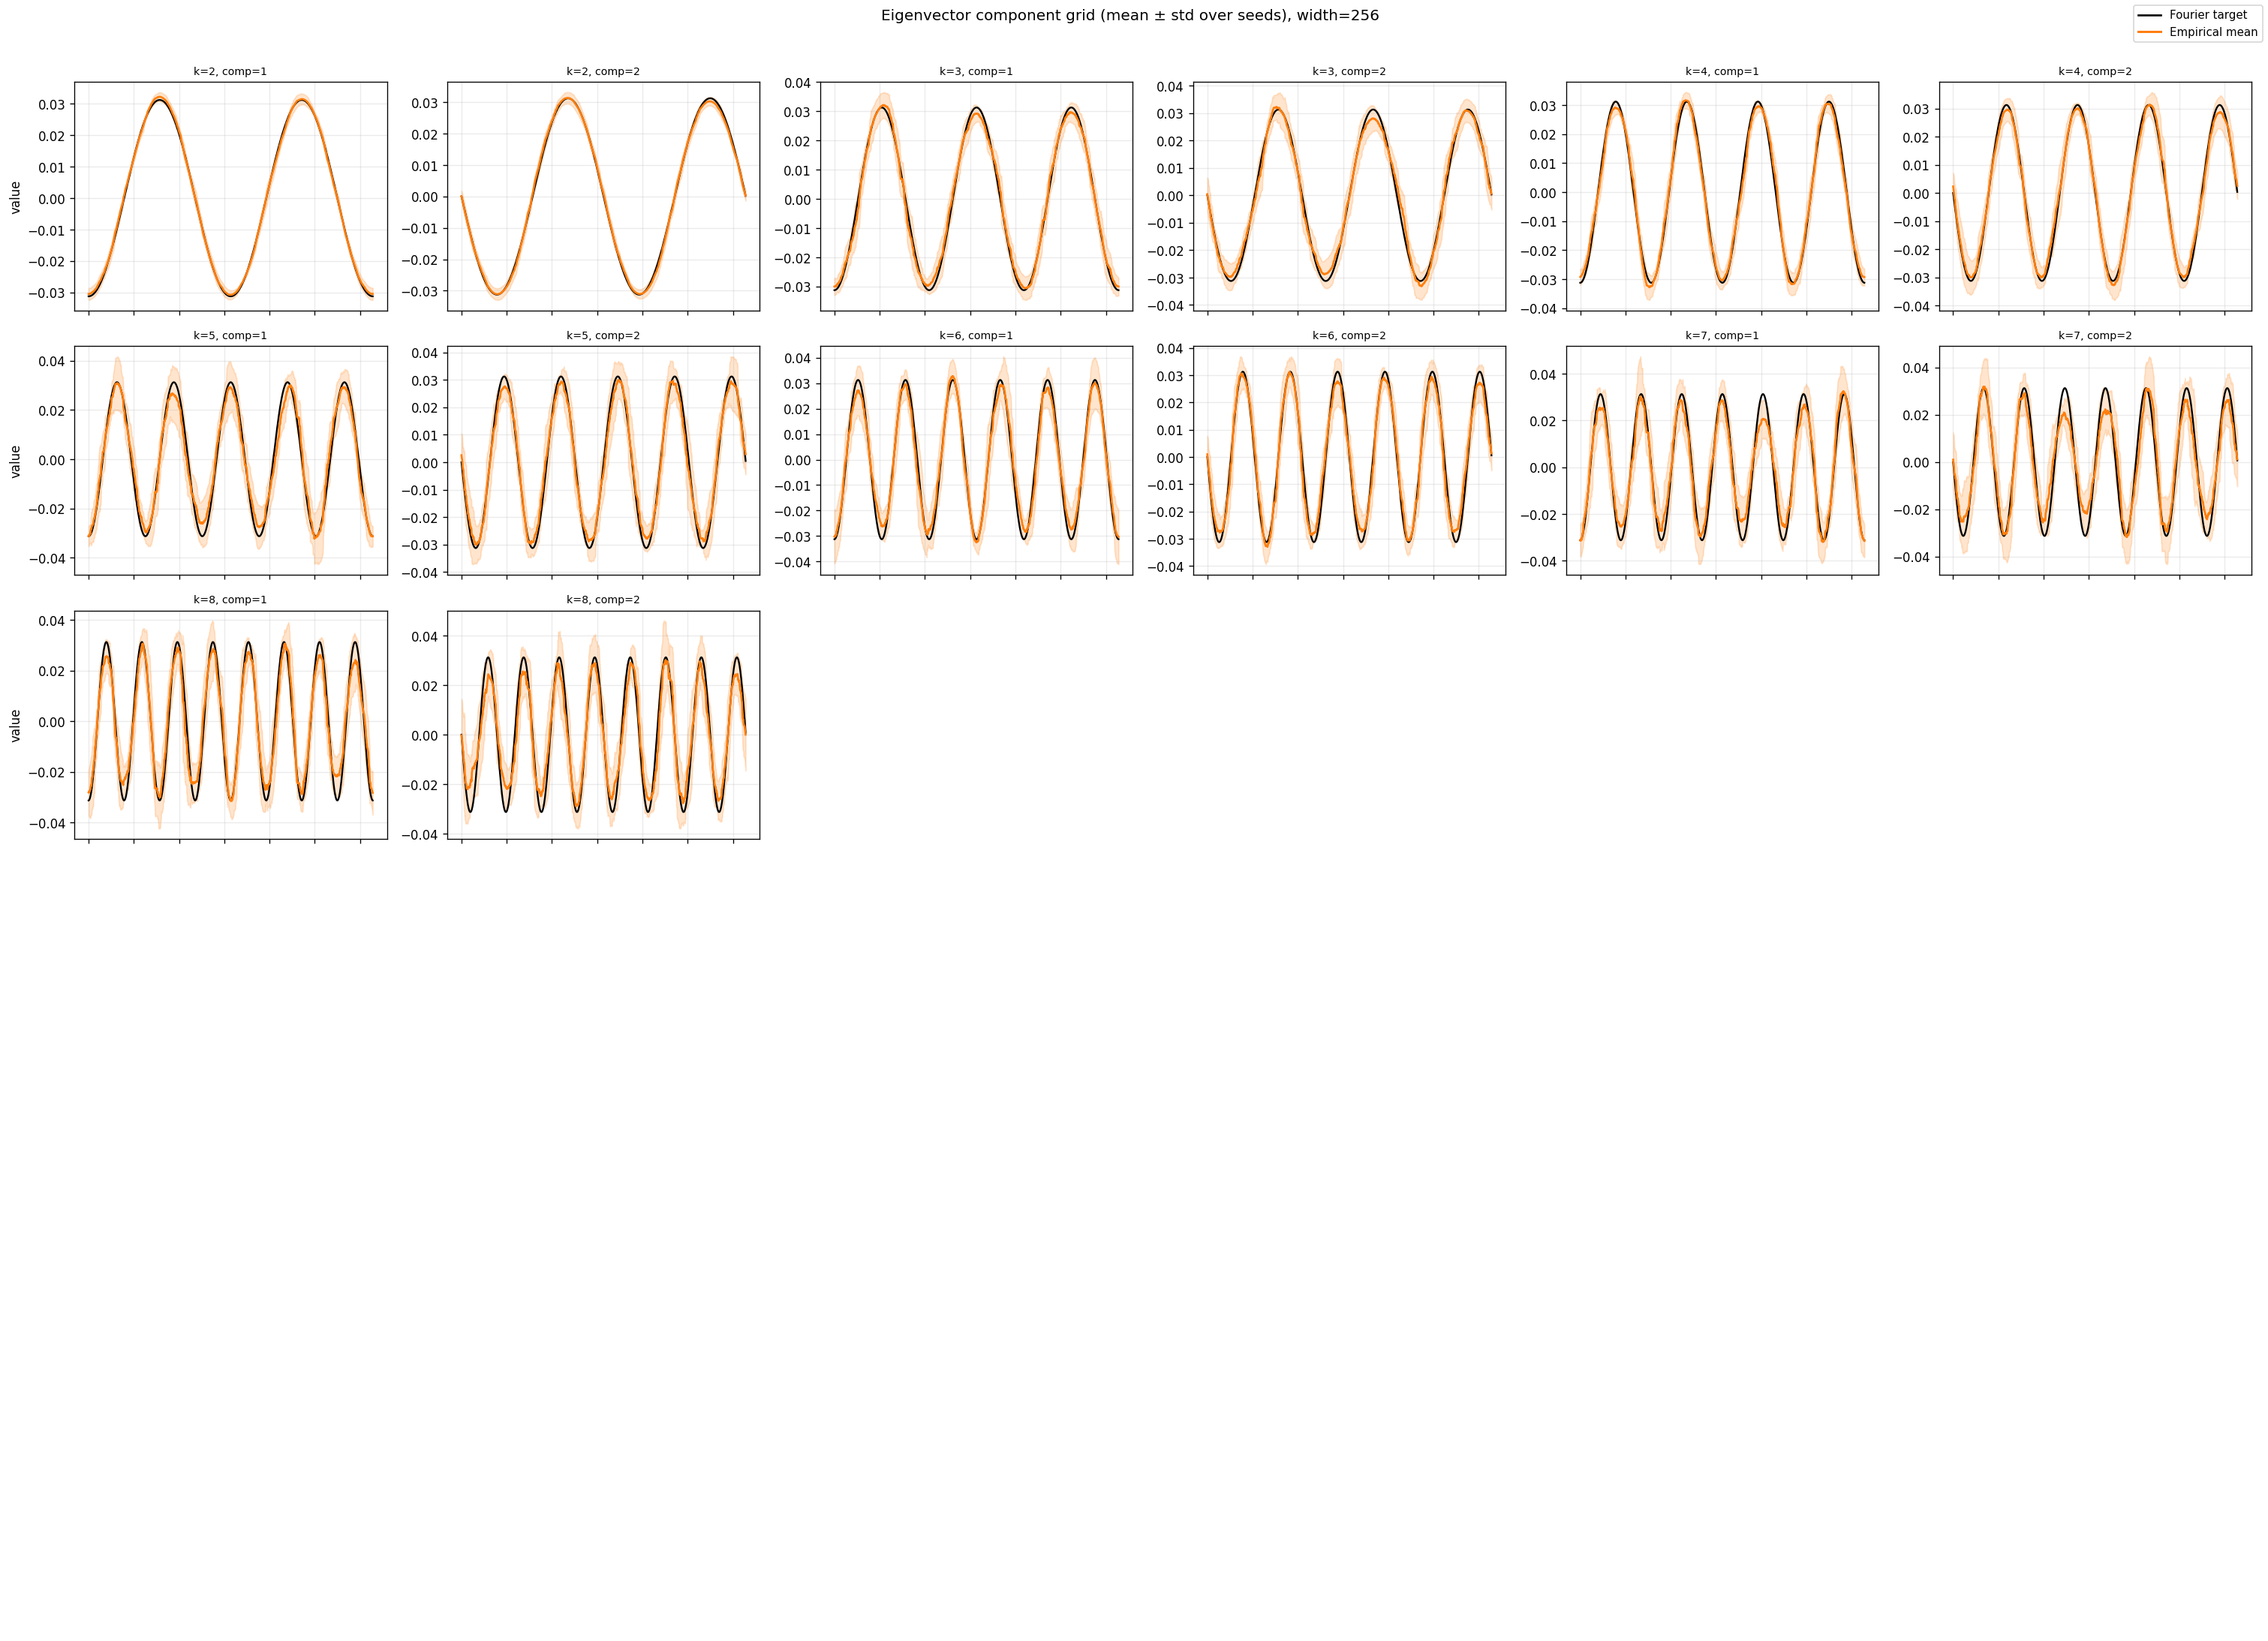

In [22]:
GRID_WIDTH = 256 #int(widths[-1])
GRID_ROWS = 6
GRID_COLS = 6
GRID_START_K = 1
GRID_INCLUDE_K0 = False

GRID_FREQS = keep_existing([2,3,4,5,6,7,8], frequencies.tolist())
GRID_FREQS = [int(k) for k in GRID_FREQS if int(k) >= GRID_START_K]
if GRID_INCLUDE_K0 and 0 in keep_existing([0], frequencies.tolist()):
    GRID_FREQS = [0] + GRID_FREQS
GRID_FREQS = sorted(set(int(k) for k in GRID_FREQS))

pairs = []  # list of (k, component_index)
for k in GRID_FREQS:
    if k == 0:
        pairs.append((0, 0))
    else:
        pairs.append((k, 0))
        pairs.append((k, 1))

if len(pairs) == 0:
    raise RuntimeError('No (k, component) pairs selected for the requested grid.')

if GRID_ROWS * GRID_COLS < len(pairs):
    GRID_ROWS = int(np.ceil(len(pairs) / GRID_COLS))
    print(f'Grid expanded to {GRID_ROWS}x{GRID_COLS} to include all selected frequencies.')

n_panels = min(len(pairs), GRID_ROWS * GRID_COLS)
pairs = pairs[:n_panels]

stats_by_k = {}
for k in sorted({k for k, _ in pairs}):
    stats_by_k[k] = aligned_components_across_seeds(GRID_WIDTH, k)

sources = sorted({stats_by_k[k]['source'] for k in stats_by_k})
print(f'Grid width={GRID_WIDTH}, panels={len(pairs)}, frequencies={sorted({k for k, _ in pairs})}, data source={sources}')

max_dim = max(GRID_ROWS, GRID_COLS)
if max_dim >= 8:
    width_per_col, height_per_row = 4.8, 3.3
    title_fs = 8
elif max_dim >= 6:
    width_per_col, height_per_row = 4.2, 3.0
    title_fs = 8.5
else:
    width_per_col, height_per_row = 3.8, 2.7
    title_fs = 9

fig, axes = plt.subplots(
    GRID_ROWS,
    GRID_COLS,
    figsize=(width_per_col * GRID_COLS, height_per_row * GRID_ROWS),
    sharex=True,
    sharey=False,
)
axes = np.asarray(axes).reshape(-1)

for idx, ax in enumerate(axes):
    if idx >= len(pairs):
        ax.axis('off')
        continue

    k, comp = pairs[idx]
    st = stats_by_k[k]
    if comp >= st['d']:
        ax.axis('off')
        continue

    y_ref = st['F'][:, comp]
    y_mean = st['mean'][comp, :]
    y_std = st['std'][comp, :]

    ax.plot(theta, y_ref, color='black', linewidth=1.4)
    ax.plot(theta, y_mean, color='C1', linewidth=1.6)
    ax.fill_between(theta, y_mean - y_std, y_mean + y_std, color='C1', alpha=0.2)

    ax.set_title(f'k={k}, comp={comp + 1}', fontsize=title_fs)
    ax.grid(True, alpha=0.25)

    if idx % GRID_COLS == 0:
        ax.set_ylabel('value')
    if idx // GRID_COLS == GRID_ROWS - 1:
        ax.set_xlabel(r'$\theta$')

legend_handles = [
    plt.Line2D([0], [0], color='black', linewidth=1.6, label='Fourier target'),
    plt.Line2D([0], [0], color='C1', linewidth=1.8, label='Empirical mean'),
]
fig.legend(handles=legend_handles, loc='upper right', fontsize=9)
fig.suptitle(
    f'Eigenvector component grid (mean ± std over seeds), width={GRID_WIDTH}',
    y=1.01,
)
fig.tight_layout()

filename = PLOT_DIR / f'eigenvector_shape_grid_{GRID_ROWS}x{GRID_COLS}_w{GRID_WIDTH}.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()


## Plot 1: Projector Error vs Width

Lower is better. Curves show how quickly Fourier-subspace alignment improves with width.

Successfully saved plots/ntk_eigenspace_alignment_on_S1/projector_error_vs_width.png


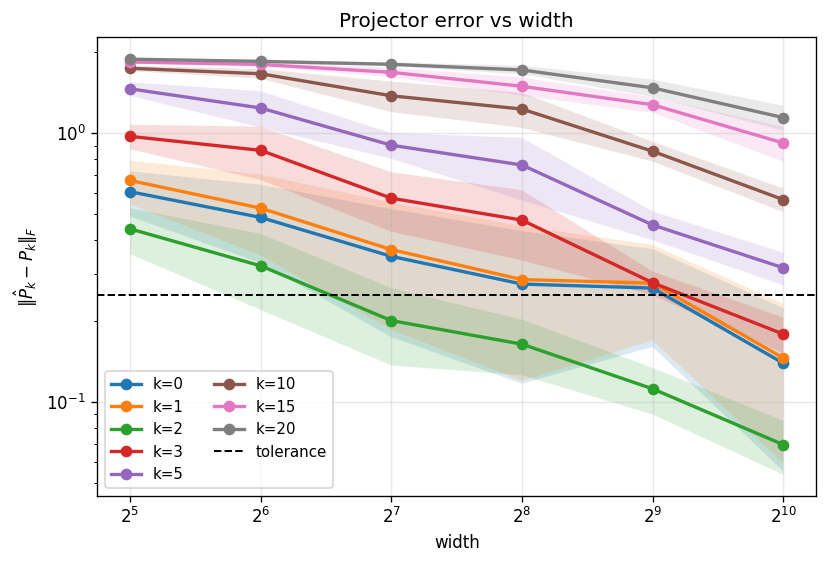

In [23]:
freqs_to_plot = keep_existing([0, 1, 2, 3, 5, 10, 15, 20], frequencies.tolist())

plt.figure(figsize=(7.0, 4.8))
for k in freqs_to_plot:
    j = fidx(k)
    y = projector_fro_mean[:, j]
    e = projector_fro_std[:, j]
    plt.plot(widths, y, marker='o', linewidth=2, label=f'k={k}')
    plt.fill_between(widths, y - e, y + e, alpha=0.16)

plt.axhline(projector_fro_tol, linestyle='--', color='black', linewidth=1.2, label='tolerance')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('width')
plt.ylabel(r'$\|\hat{P}_k - P_k\|_F$')
plt.title('Projector error vs width')
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

filename = PLOT_DIR / 'projector_error_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Plot 2: Projector Error vs Frequency

At fixed widths, this reveals which frequencies are hardest to align.

Successfully saved plots/ntk_eigenspace_alignment_on_S1/projector_error_vs_frequency.png


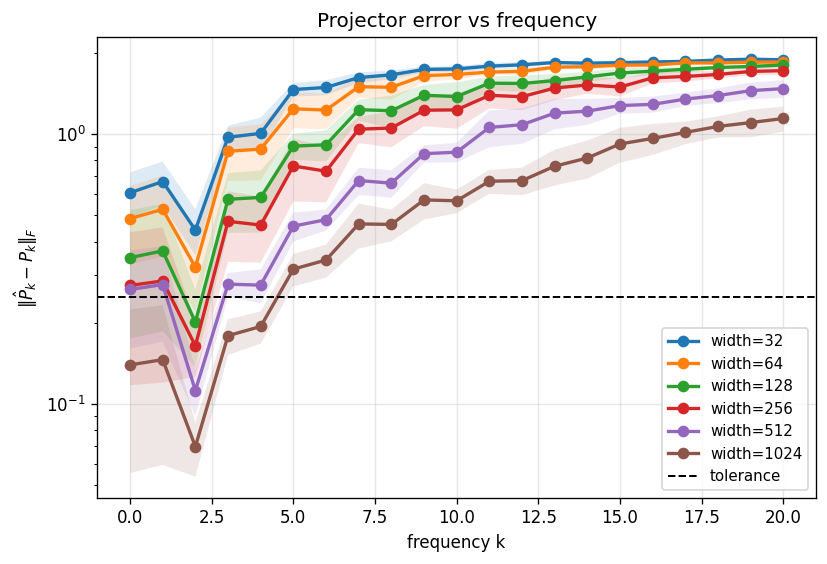

In [10]:
widths_to_plot = keep_existing([32, 64, 128, 256, 512, 1024], widths.tolist())

plt.figure(figsize=(7.0, 4.8))
for w in widths_to_plot:
    i = widx(w)
    y = projector_fro_mean[i, :]
    e = projector_fro_std[i, :]
    plt.plot(frequencies, y, marker='o', linewidth=2, label=f'width={w}')
    plt.fill_between(frequencies, y - e, y + e, alpha=0.14)

plt.axhline(projector_fro_tol, linestyle='--', color='black', linewidth=1.2, label='tolerance')
plt.yscale('log')
plt.xlabel('frequency k')
plt.ylabel(r'$\|\hat{P}_k - P_k\|_F$')
plt.title('Projector error vs frequency')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()

filename = PLOT_DIR / 'projector_error_vs_frequency.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Plot 3: Principal Angles vs Width

Angles are shown in degrees. For $k\ge 1$, there are two angles because both Fourier and matched empirical subspaces are 2D.

Successfully saved plots/ntk_eigenspace_alignment_on_S1/principal_angles_vs_width.png


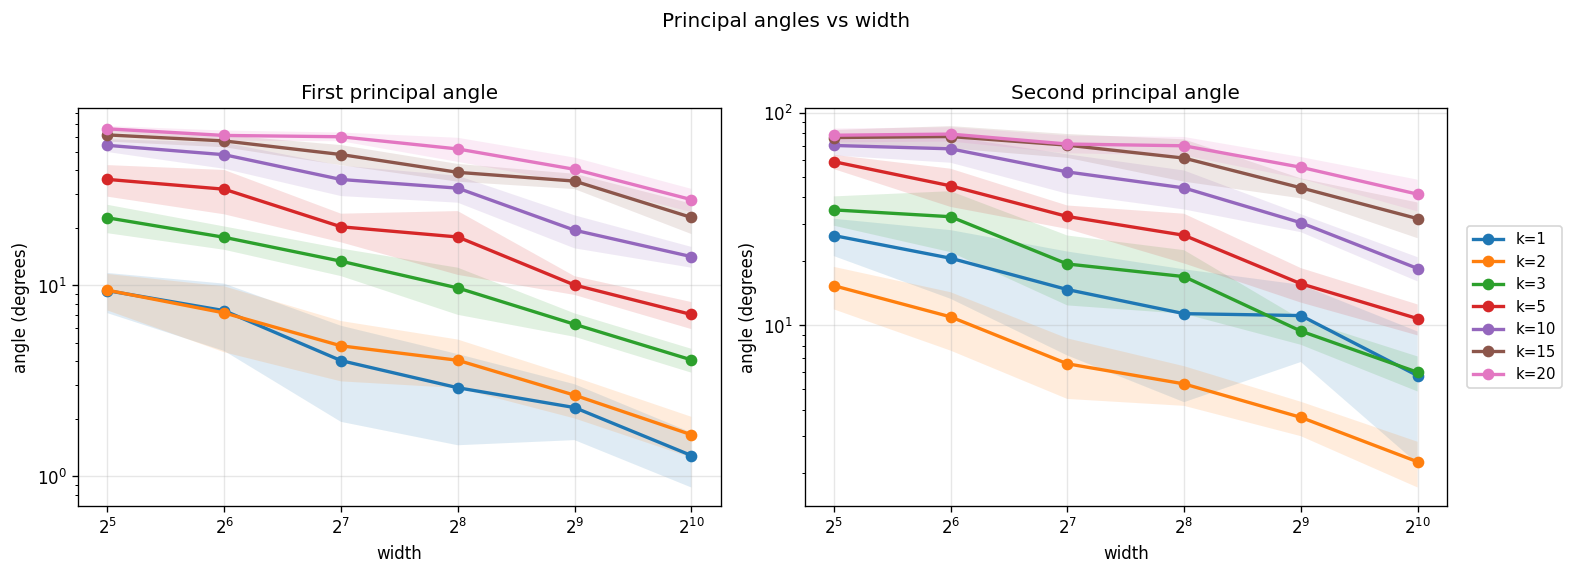

In [11]:
freqs_for_angles = keep_existing([1, 2, 3, 5, 10, 15, 20], frequencies.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), sharex=True)

for k in freqs_for_angles:
    j = fidx(k)

    a1 = np.rad2deg(principal_angles_mean[:, j, 0])
    s1 = np.rad2deg(principal_angles_std[:, j, 0])
    axes[0].plot(widths, a1, marker='o', linewidth=2, label=f'k={k}')
    axes[0].fill_between(widths, a1 - s1, a1 + s1, alpha=0.14)

    a2 = np.rad2deg(principal_angles_mean[:, j, 1])
    s2 = np.rad2deg(principal_angles_std[:, j, 1])
    axes[1].plot(widths, a2, marker='o', linewidth=2, label=f'k={k}')
    axes[1].fill_between(widths, a2 - s2, a2 + s2, alpha=0.14)

axes[0].set_xscale('log', base=2)
axes[1].set_xscale('log', base=2)
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].set_xlabel('width')
axes[1].set_xlabel('width')
axes[0].set_ylabel('angle (degrees)')
axes[1].set_ylabel('angle (degrees)')
axes[0].set_title('First principal angle')
axes[1].set_title('Second principal angle')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle('Principal angles vs width', y=1.03)
fig.tight_layout()

filename = PLOT_DIR / 'principal_angles_vs_width.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Plot 4: Eigenvalue Error vs Frequency

Left: absolute error between matched empirical eigenvalue and theory.
Right: pair splitting inside the matched 2D empirical subspace.

Successfully saved plots/ntk_eigenspace_alignment_on_S1/eigenvalue_error_vs_frequency.png


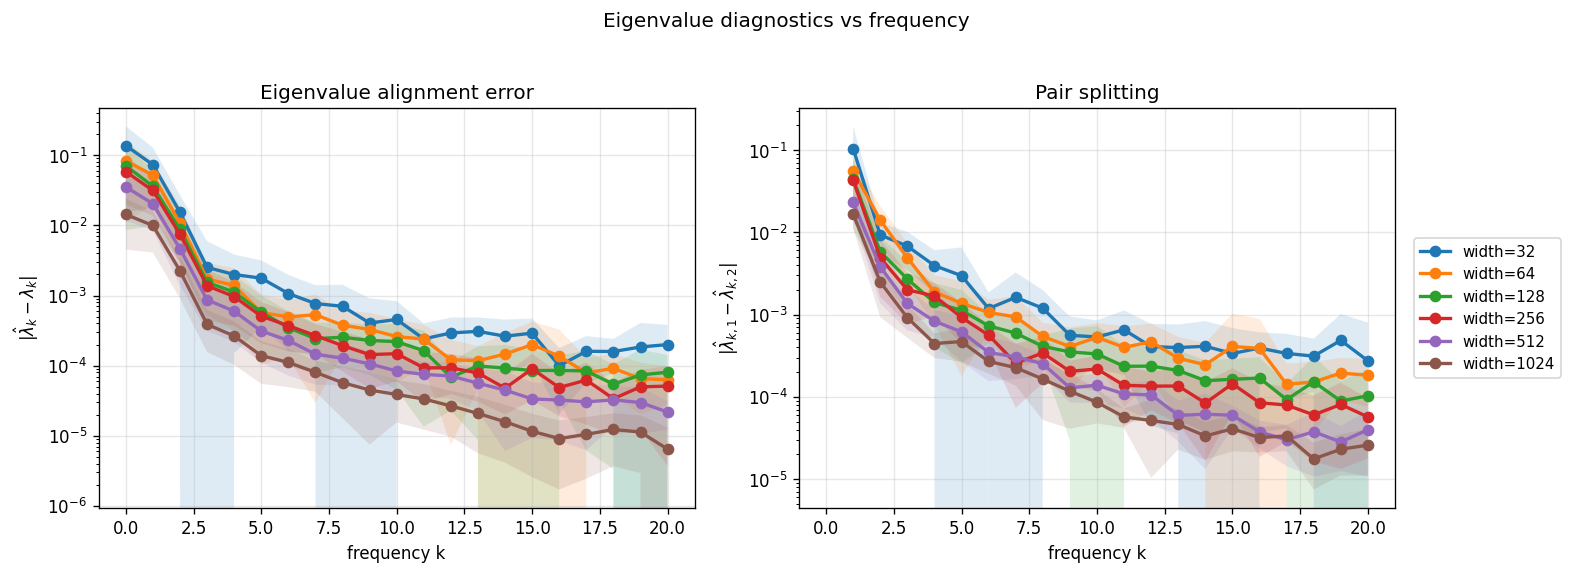

In [12]:
widths_to_plot = keep_existing([32, 64, 128, 256, 512, 1024], widths.tolist())

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), sharex=True)

for w in widths_to_plot:
    i = widx(w)

    y1 = eig_abs_error_mean[i, :]
    e1 = eig_abs_error_std[i, :]
    axes[0].plot(frequencies, y1, marker='o', linewidth=2, label=f'width={w}')
    axes[0].fill_between(frequencies, y1 - e1, y1 + e1, alpha=0.14)

    y2 = pair_splitting_mean[i, :]
    e2 = pair_splitting_std[i, :]
    axes[1].plot(frequencies, y2, marker='o', linewidth=2, label=f'width={w}')
    axes[1].fill_between(frequencies, y2 - e2, y2 + e2, alpha=0.14)

axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].set_xlabel('frequency k')
axes[1].set_xlabel('frequency k')
axes[0].set_ylabel(r'$|\hat{\lambda}_k - \lambda_k|$')
axes[1].set_ylabel(r'$|\hat{\lambda}_{k,1} - \hat{\lambda}_{k,2}|$')
axes[0].set_title('Eigenvalue alignment error')
axes[1].set_title('Pair splitting')
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)

fig.suptitle('Eigenvalue diagnostics vs frequency', y=1.03)
fig.tight_layout()

filename = PLOT_DIR / 'eigenvalue_error_vs_frequency.png'
plt.savefig(filename, bbox_inches='tight')
print(f'Successfully saved {filename}')
plt.show()

## Diagnostics

Summarize minimum width achieving small projector error and frequencies that still fail at the largest width.

In [13]:
print(f'Projector Frobenius tolerance: {projector_fro_tol:.4g}')
print('')
print('Minimum width for small projector error by frequency:')
for k, w in zip(frequencies, min_width_for_small_error):
    tag = 'not reached' if int(w) < 0 else str(int(w))
    print(f'  k={int(k):2d}: {tag}')

print('')
if len(failing_freqs_at_max_width) == 0:
    print('All frequencies satisfy tolerance at largest width.')
else:
    print(
        'Frequencies failing tolerance at largest width',
        int(widths[-1]),
        ':',
        failing_freqs_at_max_width.tolist(),
    )

Projector Frobenius tolerance: 0.25

Minimum width for small projector error by frequency:
  k= 0: 1024
  k= 1: 1024
  k= 2: 128
  k= 3: 1024
  k= 4: 1024
  k= 5: not reached
  k= 6: not reached
  k= 7: not reached
  k= 8: not reached
  k= 9: not reached
  k=10: not reached
  k=11: not reached
  k=12: not reached
  k=13: not reached
  k=14: not reached
  k=15: not reached
  k=16: not reached
  k=17: not reached
  k=18: not reached
  k=19: not reached
  k=20: not reached

Frequencies failing tolerance at largest width 1024 : [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
